**BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation**
Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin).

knn - tree, XGBoost, Logistic Regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_score, recall_score, f1_score, precision_recall_fscore_support,
                           balanced_accuracy_score, make_scorer)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
print(df.shape)
if 'Job_Status_num' not in df.columns:
    print("ERREUR: Colonne 'Growth_Category' introuvable!")
    print(f"   Colonnes disponibles: {df.columns.tolist()}")
else:
    print(f"Target trouvée: Job_Status_num")

(10000, 29)
Target trouvée: Job_Status_num


In [29]:
# Load the prepared dataset
df =  pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")
print(f"Dataset shape: {df.shape}")
# Vérification de la target
if 'Job_Status_num' not in df.columns:
    print("ERREUR: Colonne 'Job_Status_num' introuvable!")
    print(f"   Colonnes disponibles: {df.columns.tolist()}")
else:
    print(f"Target trouvée: Job_Status_num")

Dataset shape: (10000, 29)
Target trouvée: Job_Status_num


In [30]:
# Check Job_Status_num distribution
print("\n📊 Distribution de Job_Status_num:")
print(df['Job_Status_num'].value_counts())
print(f"Proportions:\n{df['Job_Status_num'].value_counts(normalize=True)}")

# Verify the encoding mapping
job_status_mapping = {
    0.0: 'decreasing',
    1.0: 'increasing'
}
print(f"\n🎯 Job_Status_num mapping: {job_status_mapping}")


📊 Distribution de Job_Status_num:
Job_Status_num
-0.996207    5019
 1.003807    4981
Name: count, dtype: int64
Proportions:
Job_Status_num
-0.996207    0.5019
 1.003807    0.4981
Name: proportion, dtype: float64

🎯 Job_Status_num mapping: {0.0: 'decreasing', 1.0: 'increasing'}


Data Preparation with Job_Status_num


In [31]:
# Prepare target variable - USING JOB_STATUS_NUM
target = "Job_Status_num"

# Remove leakage features and prepare X
LEAKAGE_FEATURES = [
    'Job_Growth_Rate_%',       
    'Growth_Category',          
    'Job_Status_num'           
]

X = df.select_dtypes(include=[np.number]).copy()
X = X.drop(columns=[col for col in LEAKAGE_FEATURES if col in X.columns], errors='ignore')
y = df[target].copy()

print(f"\nTarget variable: {target}")
print(f"Features used: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")
print(f"Target mapping: {job_status_mapping}")




Target variable: Job_Status_num
Features used: 25
Target distribution:
Job_Status_num
-0.996207    5019
 1.003807    4981
Name: count, dtype: int64
Target mapping: {0.0: 'decreasing', 1.0: 'increasing'}


In [32]:
class_names = ['decreasing', 'increasing']
y_encoded = y.astype(int)  # Ensure it's integer type

print(f"\nClasses: {class_names}")
print(f"Class distribution: {dict(zip(class_names, np.bincount(y_encoded)))}")



Classes: ['decreasing', 'increasing']
Class distribution: {'decreasing': 5019, 'increasing': 4981}


# Split the data


In [33]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n📈 Data Split:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target distribution: {dict(zip(class_names, np.bincount(y_train)))}")


📈 Data Split:
Training set: (8000, 25)
Test set: (2000, 25)
Training target distribution: {'decreasing': 4015, 'increasing': 3985}


In [34]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE (if needed)
print(f"\n🔄 Class balance check:")
print(f"Before SMOTE: {dict(zip(class_names, np.bincount(y_train)))}")

# Use SMOTE only if there's significant imbalance
if abs(np.bincount(y_train)[0] - np.bincount(y_train)[1]) / len(y_train) > 0.1:
    smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=3)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f"After SMOTE: {dict(zip(class_names, np.bincount(y_train_smote)))}")
    X_train_final, y_train_final = X_train_smote, y_train_smote
else:
    X_train_final, y_train_final = X_train_scaled, y_train
    print("No SMOTE applied - classes are balanced enough")


🔄 Class balance check:
Before SMOTE: {'decreasing': 4015, 'increasing': 3985}
No SMOTE applied - classes are balanced enough


# **KNN**

In [35]:
# KNN Baseline
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)
y_pred_knn_baseline = knn_baseline.predict(X_test_scaled)
acc_knn_baseline = accuracy_score(y_test, y_pred_knn_baseline)


print(f" KNN Baseline - Accuracy: {acc_knn_baseline:.3f}")
print("\nRapport de classification KNN basique :")
print(classification_report(y_test, y_pred_knn_baseline, target_names=class_names))


 KNN Baseline - Accuracy: 0.494

Rapport de classification KNN basique :
              precision    recall  f1-score   support

  decreasing       0.50      0.51      0.50      1004
  increasing       0.49      0.48      0.48       996

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



**Optimisation KNN avec GridSearchCV**

In [36]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
# Utiliser balanced_accuracy comme métrique
knn_grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid_knn, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train_smote, y_train_smote)

best_knn = knn_grid.best_estimator_
y_pred_knn_opt = best_knn.predict(X_test_scaled)
acc_knn_opt = accuracy_score(y_test, y_pred_knn_opt)
bal_acc_knn = balanced_accuracy_score(y_test, y_pred_knn_opt)

**evaluation**

In [37]:
print(f" KNN OPTIMISÉ - Performances:")
print(f"   • Accuracy: {acc_knn_opt:.4f}")
print(f"   • Balanced Accuracy: {bal_acc_knn:.4f}")
print(f"   • Meilleurs paramètres: {knn_grid.best_params_}")

print("\nRapport de classification KNN optimisé :")
print(classification_report(y_test, y_pred_knn_opt, target_names=class_names))

 KNN OPTIMISÉ - Performances:
   • Accuracy: 0.5075
   • Balanced Accuracy: 0.5075
   • Meilleurs paramètres: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}

Rapport de classification KNN optimisé :
              precision    recall  f1-score   support

  decreasing       0.51      0.50      0.51      1004
  increasing       0.51      0.51      0.51       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



**visualisation**

Matrice de confusion

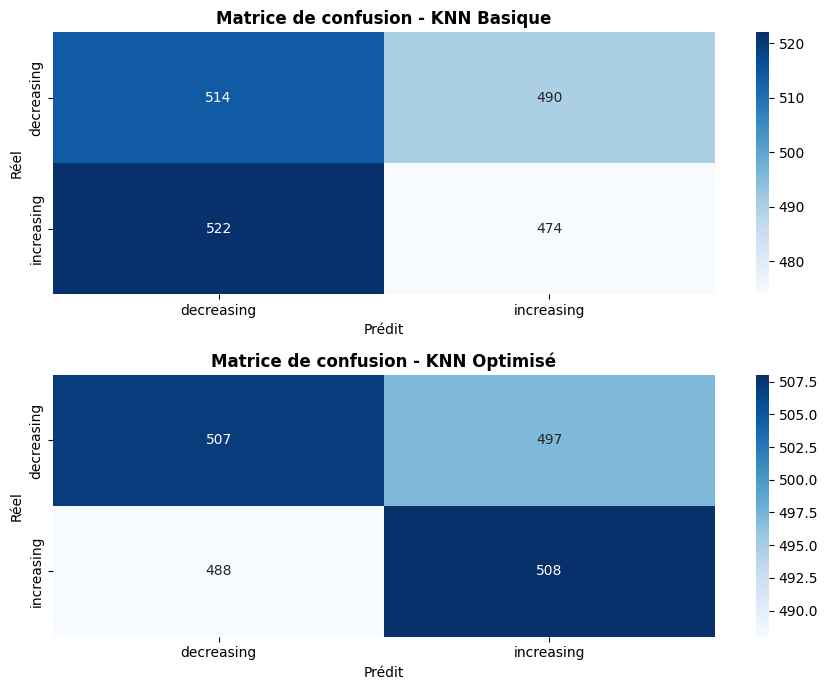

In [39]:
plt.figure(figsize=(9, 7))
plt.subplot(2, 1, 1)
cm_basic = confusion_matrix(y_test, y_pred_knn_baseline)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)  # Correction: class_names
plt.title("Matrice de confusion - KNN Basique", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.subplot(2, 1, 2)
cm_opt = confusion_matrix(y_test, y_pred_knn_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)  # Correction: class_names
plt.title("Matrice de confusion - KNN Optimisé", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

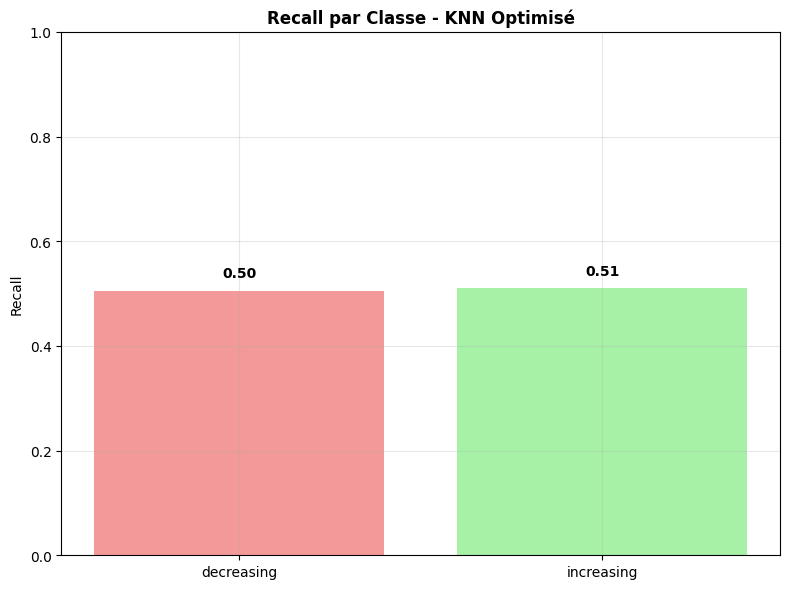

In [40]:
plt.figure(figsize=(8, 6))
recall_knn = recall_score(y_test, y_pred_knn_opt, average=None)
plt.bar(class_names, recall_knn, color=['lightcoral', 'lightgreen'], alpha=0.8)  # Correction: 2 couleurs seulement
plt.title('Recall par Classe - KNN Optimisé', fontweight='bold')
plt.ylabel('Recall')
plt.ylim(0, 1)
for i, v in enumerate(recall_knn):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

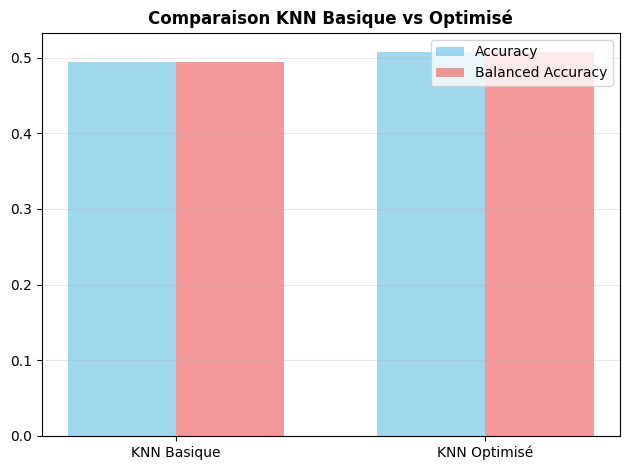

In [41]:
models_comparison_knn = pd.DataFrame({
    'Modèle': ['KNN Basique', 'KNN Optimisé'],
    'Accuracy': [acc_knn_baseline, acc_knn_opt],
    'Balanced Accuracy': [balanced_accuracy_score(y_test, y_pred_knn_baseline), bal_acc_knn]
})
x_pos = np.arange(len(models_comparison_knn))
width = 0.35
plt.bar(x_pos - width/2, models_comparison_knn['Accuracy'], width, 
        label='Accuracy', alpha=0.8, color='skyblue')
plt.bar(x_pos + width/2, models_comparison_knn['Balanced Accuracy'], width, 
        label='Balanced Accuracy', alpha=0.8, color='lightcoral')
plt.title('Comparaison KNN Basique vs Optimisé', fontweight='bold')
plt.xticks(x_pos, models_comparison_knn['Modèle'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

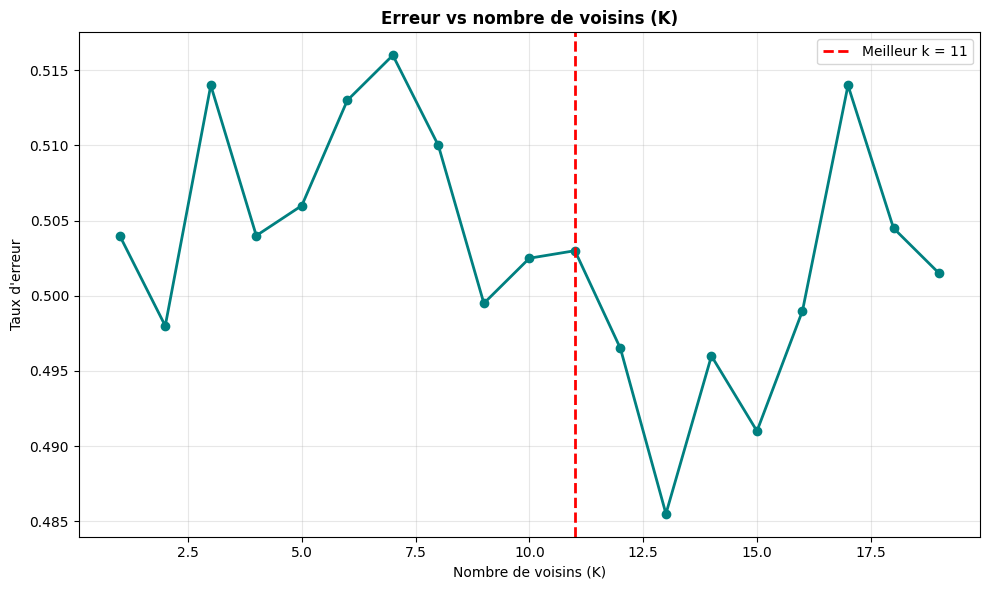

In [42]:
plt.figure(figsize=(10, 6))
errors = []
neighbors_range = range(1, 20)
for k in neighbors_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred_k = model.predict(X_test_scaled)
    errors.append(1 - accuracy_score(y_test, pred_k))

plt.plot(neighbors_range, errors, marker='o', linestyle='-', color='teal', linewidth=2, markersize=6)
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Meilleur k = {knn_grid.best_params_["n_neighbors"]}', linewidth=2)
plt.title("Erreur vs nombre de voisins (K)", fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **Modèle Arbre de Décision** 


In [43]:
# Arbre Baseline
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree_baseline = tree_baseline.predict(X_test)
acc_tree_baseline = accuracy_score(y_test, y_pred_tree_baseline)

In [44]:

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree_baseline:.3f}")
print(f"   • Profondeur: {tree_baseline.get_depth()}")
print(f"   • Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.508
   • Profondeur: 37
   • Feuilles: 1969


**Optimisation Arbre**

In [45]:
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree_baseline = tree_baseline.predict(X_test)
acc_tree_baseline = accuracy_score(y_test, y_pred_tree_baseline)

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree_baseline:.3f}")
print(f"  Profondeur: {tree_baseline.get_depth()}")
print(f"  Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.508
  Profondeur: 37
  Feuilles: 1969


**Optimisation Arbre avec GridSearchCV**

In [46]:
param_grid_tree = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', {0:1, 1:1}],  # Correction: seulement 2 classes
    'max_features': ['sqrt', 'log2', None]
}

grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_tree.fit(X_train_final, y_train_final)  # Utiliser les données finales



Fitting 5 folds for each of 540 candidates, totalling 2700 fits
ARBRE OPTIMISÉ - Performances:
  • Accuracy: 0.5100
  • Balanced Accuracy: 0.5096
  • Meilleurs paramètres: {'class_weight': {0: 1, 1: 1}, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 10}

Rapport de classification Arbre optimisé :
              precision    recall  f1-score   support

  decreasing       0.51      0.61      0.56      1004
  increasing       0.51      0.40      0.45       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.51      0.50      2000



In [47]:
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)  # Pas de scaling pour les arbres
acc_tree = accuracy_score(y_test, y_pred_tree)
bal_acc_tree = balanced_accuracy_score(y_test, y_pred_tree)

print(f"ARBRE OPTIMISÉ - Performances:")
print(f"  • Accuracy: {acc_tree:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_tree:.4f}")
print(f"  • Meilleurs paramètres: {grid_search_tree.best_params_}")

print("\nRapport de classification Arbre optimisé :")
print(classification_report(y_test, y_pred_tree, target_names=class_names))

ARBRE OPTIMISÉ - Performances:
  • Accuracy: 0.5100
  • Balanced Accuracy: 0.5096
  • Meilleurs paramètres: {'class_weight': {0: 1, 1: 1}, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 10}

Rapport de classification Arbre optimisé :
              precision    recall  f1-score   support

  decreasing       0.51      0.61      0.56      1004
  increasing       0.51      0.40      0.45       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.51      0.50      2000



# Validation Croisée Arbre


In [48]:
cv_scores_tree = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nVALIDATION CROISÉE ARBRE:")
print(f"  • Scores CV: {[f'{s:.4f}' for s in cv_scores_tree]}")
print(f"  • Moyenne:   {cv_scores_tree.mean():.4f} (± {cv_scores_tree.std():.4f})")

# Importance des features
importances_tree = pd.Series(best_tree.feature_importances_, index=X.columns)
importances_tree = importances_tree.sort_values(ascending=False)
top_features_tree = importances_tree[importances_tree > 0].head(15)

print(f"\nTOP {len(top_features_tree)} FEATURES IMPORTANTES - ARBRE:")
for i, (feature, importance) in enumerate(top_features_tree.items(), 1):
   
    print(f"   {i:2d}. {feature:35} {importance:7.4f} ")


VALIDATION CROISÉE ARBRE:
  • Scores CV: ['0.4981', '0.5162', '0.5150', '0.4781', '0.4963']
  • Moyenne:   0.5007 (± 0.0140)

TOP 15 FEATURES IMPORTANTES - ARBRE:
    1. Median_Salary_USD                    0.1494 
    2. Gender_Diversity_%                   0.1429 
    3. Job_Value_Index                      0.1354 
    4. Remote_Work_Ratio_%                  0.1172 
    5. Vulnerability_Index                  0.1116 
    6. Automation_Risk_%                    0.1061 
    7. Required_Education_num               0.0705 
    8. Experience_Required_Years            0.0685 
    9. Location_canada                      0.0161 
   10. Location_china                       0.0157 
   11. Location_brazil                      0.0126 
   12. Industry_education                   0.0086 
   13. Industry_finance                     0.0081 
   14. AI_Impact_Level_num                  0.0065 
   15. Location_germany                     0.0057 


**Visualisations Arbre**


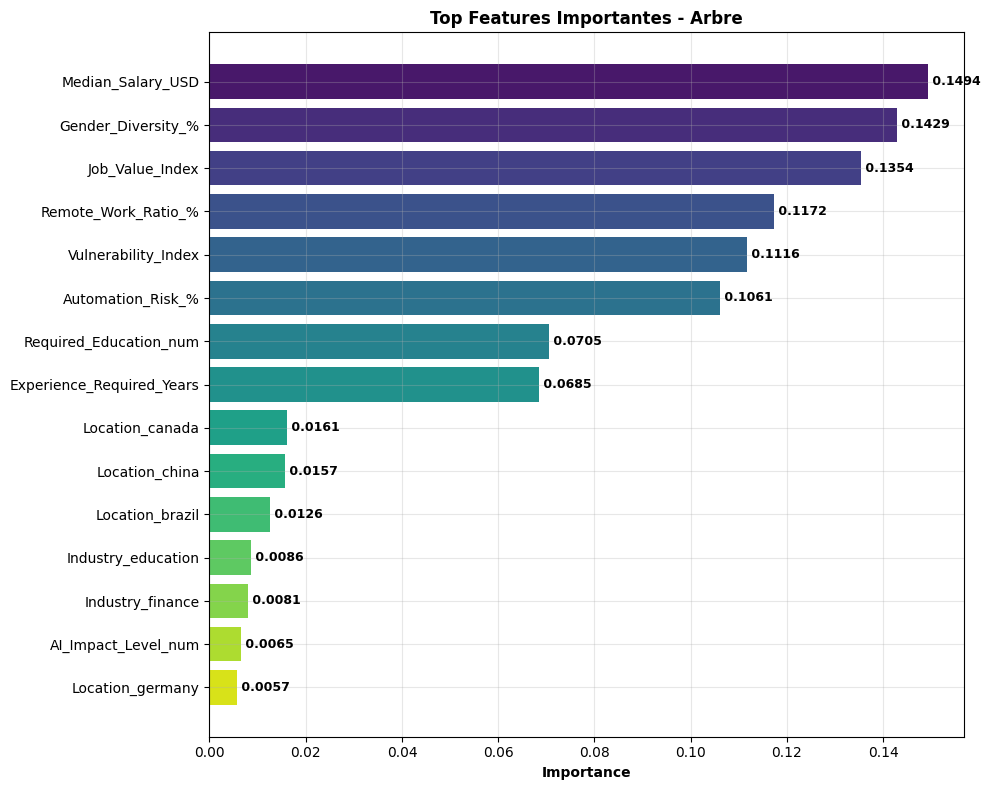

In [49]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(top_features_tree))
bars = plt.barh(range(len(top_features_tree)), top_features_tree.values, color=colors)
plt.yticks(range(len(top_features_tree)), top_features_tree.index)
plt.xlabel('Importance', fontweight='bold')
plt.title('Top Features Importantes - Arbre', fontweight='bold')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_features_tree.values)):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

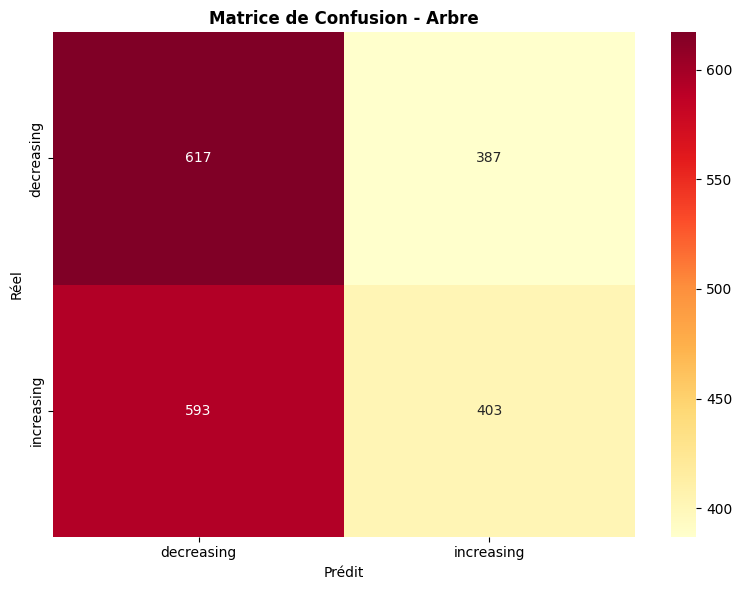

In [50]:
plt.figure(figsize=(8, 6))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)  # Correction: class_names
plt.title('Matrice de Confusion - Arbre', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

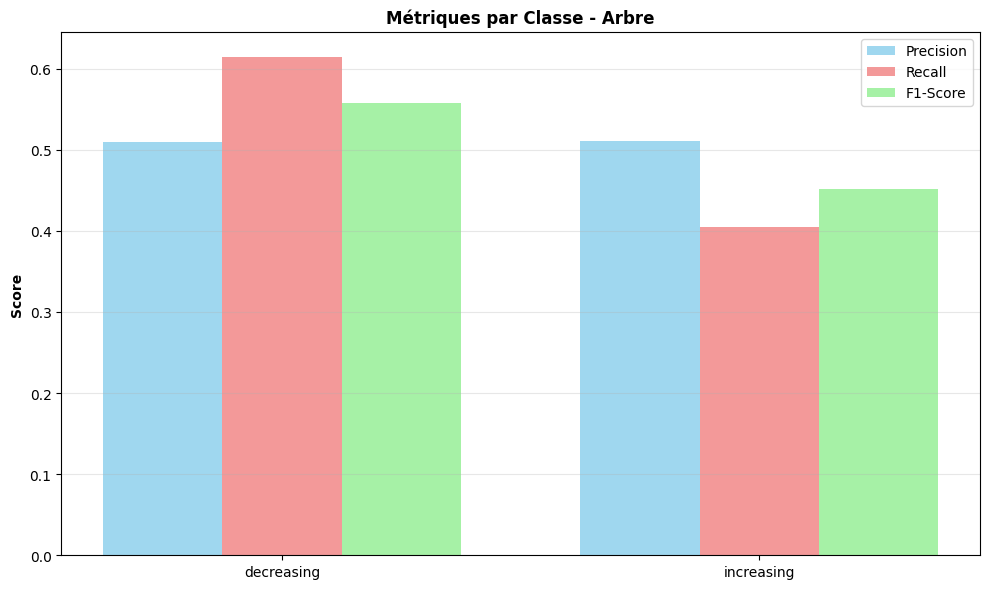

In [53]:
plt.figure(figsize=(10, 6))
precision_tree, recall_tree, f1_tree, _ = precision_recall_fscore_support(y_test, y_pred_tree, average=None)
x_pos = np.arange(len(class_names))
width = 0.25
plt.bar(x_pos - width, precision_tree, width, label='Precision', alpha=0.8, color='skyblue')
plt.bar(x_pos, recall_tree, width, label='Recall', alpha=0.8, color='lightcoral')
plt.bar(x_pos + width, f1_tree, width, label='F1-Score', alpha=0.8, color='lightgreen')
plt.ylabel('Score', fontweight='bold')
plt.title('Métriques par Classe - Arbre', fontweight='bold')
plt.xticks(x_pos, class_names)  # Correction: class_names
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

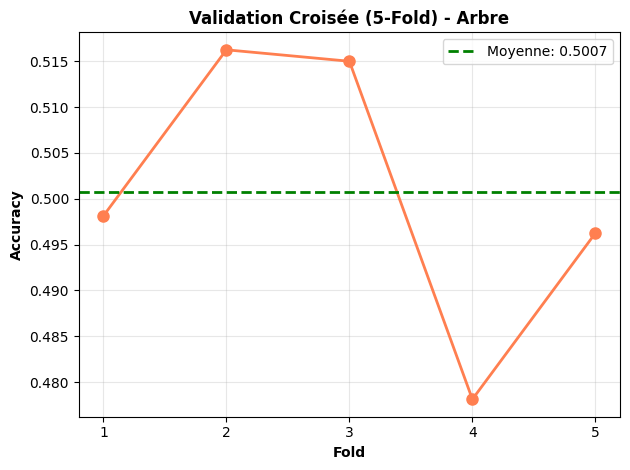

In [54]:
plt.plot(range(1, 6), cv_scores_tree, 'o-', linewidth=2, markersize=8, color='coral')
plt.axhline(cv_scores_tree.mean(), color='green', linestyle='--', 
           label=f'Moyenne: {cv_scores_tree.mean():.4f}', linewidth=2)
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Validation Croisée (5-Fold) - Arbre', fontweight='bold')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

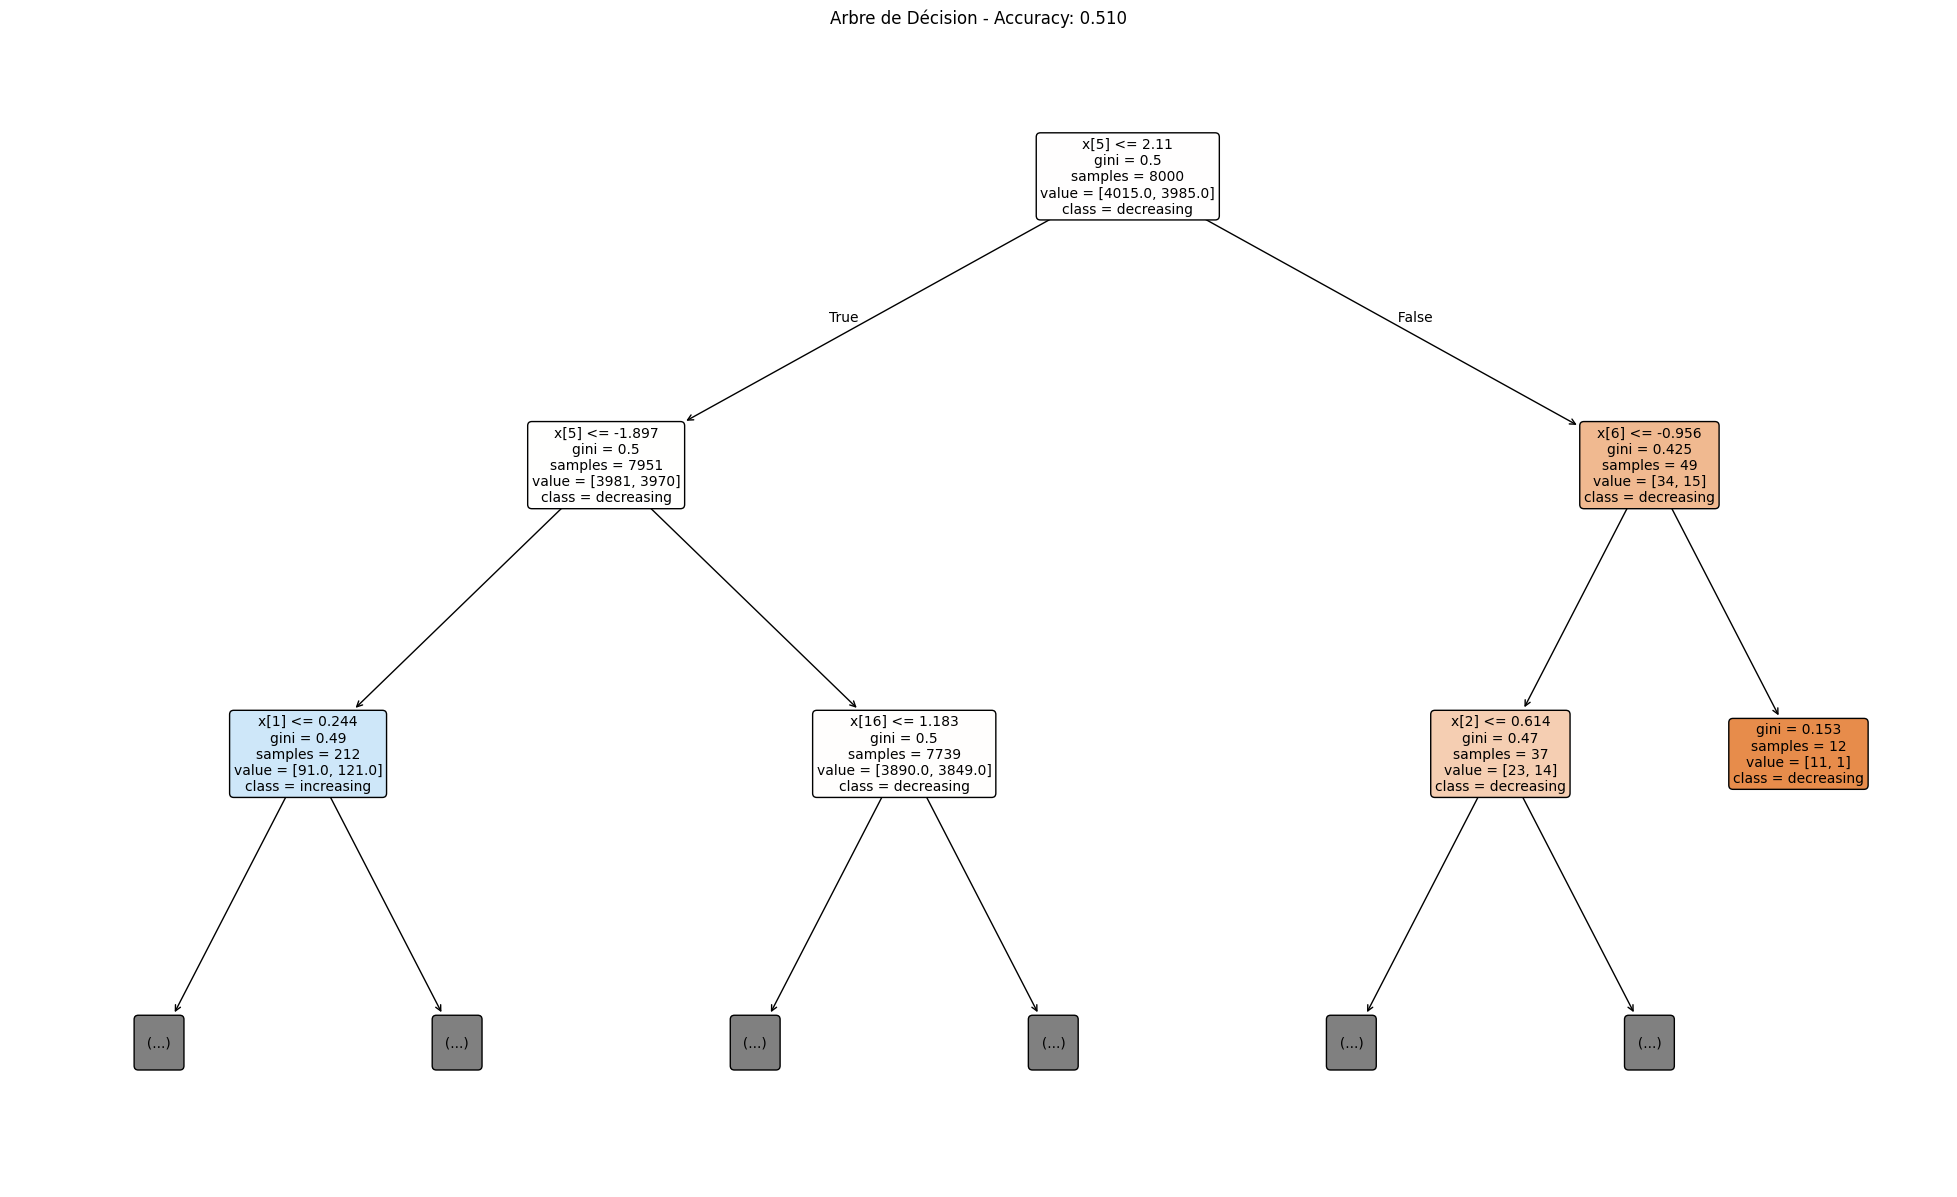

In [58]:
fig = plt.figure(figsize=(25, 15))
plot_tree(best_tree,
         class_names=class_names,
         filled=True,
         rounded=True,
         fontsize=10,
         max_depth=2)  # Show only 2 levels
plt.title(f'Arbre de Décision - Accuracy: {acc_tree:.3f}')
plt.show()

# **Régression Linéaire**


In [59]:
# Regression Baseline
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)

print(f"Regression Baseline - Accuracy: {acc_lr_baseline:.3f}")

Regression Baseline - Accuracy: 0.514


In [60]:
# Optimisation Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', {0:1, 1:1, 2:3}]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
print("Recherche des meilleurs paramètres pour la regression...")
lr_grid.fit(X_train_smote, y_train_smote)

Recherche des meilleurs paramètres pour la regression...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...], 'class_weight': ['balanced', {0: 1, 1: 1, 2: 3}], 'penalty': ['l1', 'l2', ...], 'solver': ['liblinear', 'saga']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [62]:
best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)

print(f" RÉGRESSION OPTIMISÉE - Performances:")
print(f"  • Accuracy: {acc_lr:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_lr:.4f}")
print(f"  • Meilleurs paramètres: {lr_grid.best_params_}")

print("\n Rapport de classification Regression optimisée :")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

 RÉGRESSION OPTIMISÉE - Performances:
  • Accuracy: 0.5180
  • Balanced Accuracy: 0.5181
  • Meilleurs paramètres: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}

 Rapport de classification Regression optimisée :
              precision    recall  f1-score   support

  decreasing       0.52      0.49      0.51      1004
  increasing       0.52      0.55      0.53       996

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000



# **XGboost**

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [81]:
# Chargement du fichier
df = pd.read_csv('C:\Users\meria\Downloads\mlProject\dataset_reduit.csv')

print(f"Dataset chargé avec succès !")
print(f"Shape: {df.shape}")
print(f"Colonnes: {list(df.columns)}")
print("\nAperçu des 5 premières lignes :")
print(df.head())

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1870564458.py, line 2)

In [82]:
# --- VÉRIFICATION DES COLONNES REQUISES ---
required_columns = [
    'Job_Title', 'Growth_Category', 'AI_Impact_Level'
]

missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"\nERREUR : Colonnes manquantes : {missing_cols}")
    print("Assure-toi que les noms de colonnes correspondent exactement.")
else:
    print("Toutes les colonnes nécessaires sont présentes !")

Toutes les colonnes nécessaires sont présentes !


PREPARATION DES DONNEES POUR XGBOOST (BO1: Classification du Job Status)
Mapping Growth Category: {'decline': 0, 'high_growth': 1, 'stable': 2}
Features used for classification: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']
Target variable: Growth_Category
Shape of X: (10000, 7)
Shape of y: (10000,)

ENTRAINEMENT DU MODÈLE XGBOOST


Modèle XGBoost entraîné avec succès!

ÉVALUATION DU MODÈLE
Accuracy: 0.4415

Classification Report:
              precision    recall  f1-score   support

     decline       0.45      0.49      0.47       910
 high_growth       0.44      0.48      0.46       903
      stable       0.05      0.01      0.01       187

    accuracy                           0.44      2000
   macro avg       0.31      0.33      0.31      2000
weighted avg       0.41      0.44      0.42      2000


IMPORTANCE DES FEATURES
Feature  Importance
    PC7    0.149695
    PC6    0.146388
    PC4    0.144329
    PC1    0.141749
    PC2    0.140813
    PC3    0.139857
    PC5    0.137170


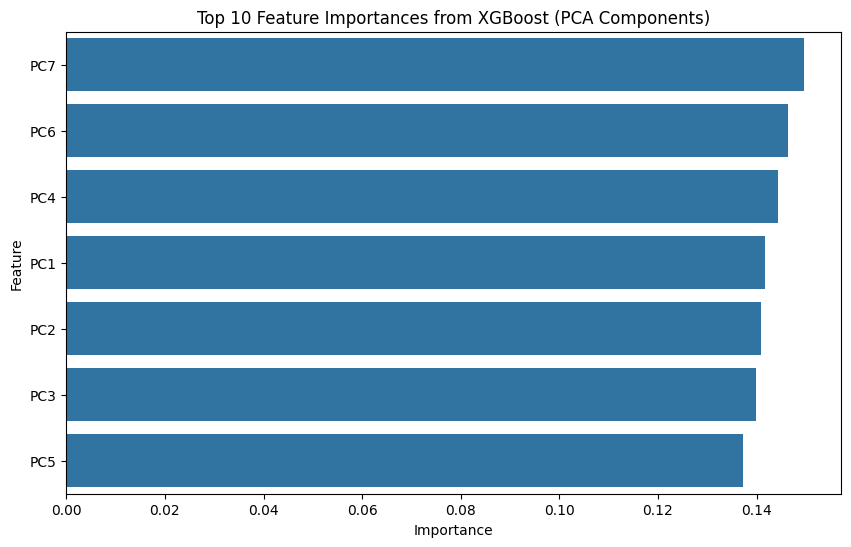

In [83]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# --- PREPARATION DES DONNEES ---
print("="*60)
print("PREPARATION DES DONNEES POUR XGBOOST (BO1: Classification du Job Status)")
print("="*60)

# The current 'df' is the 'dataset_reduit' DataFrame from the PCA step.
# It contains PCA components (PC1 to PC18) and original categorical columns (Job_Title, Growth_Category, AI_Impact_Level).

# For Business Objective 1 (BO1): "Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin)"
# The target variable should be 'Growth_Category'.

# Encode the target variable 'Growth_Category'
le_growth_category = LabelEncoder()
df['Growth_Category_encoded'] = le_growth_category.fit_transform(df['Growth_Category'])

print(f"Mapping Growth Category: {dict(zip(le_growth_category.classes_, le_growth_category.transform(le_growth_category.classes_)))}")

# Features are the PCA components (PC1 to PC18)
# Get all columns that start with 'PC'
features_bo1 = [col for col in df.columns if col.startswith('PC')]

# Define X (features) and y (target)
X = df[features_bo1]
y = df['Growth_Category_encoded']

print(f"Features used for classification: {features_bo1}")
print(f"Target variable: Growth_Category")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*60)
print("ENTRAINEMENT DU MODÈLE XGBOOST")
print("="*60)

# Initialize and train the XGBoost Classifier
# Use 'objective="multi:softmax"' for multi-class classification and 'num_class' for the number of classes
model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le_growth_category.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)
model.fit(X_train, y_train)

print("Modèle XGBoost entraîné avec succès!")

# --- ÉVALUATION DU MODÈLE ---
print("\n" + "="*60)
print("ÉVALUATION DU MODÈLE")
print("="*60)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_growth_category.classes_))

# Feature Importance
print("\n" + "="*60)
print("IMPORTANCE DES FEATURES")
print("="*60)

# Get feature importance from the trained model
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10).to_string(index=False))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances from XGBoost (PCA Components)')
plt.show()

AttributeError: 'list' object has no attribute 'mean'

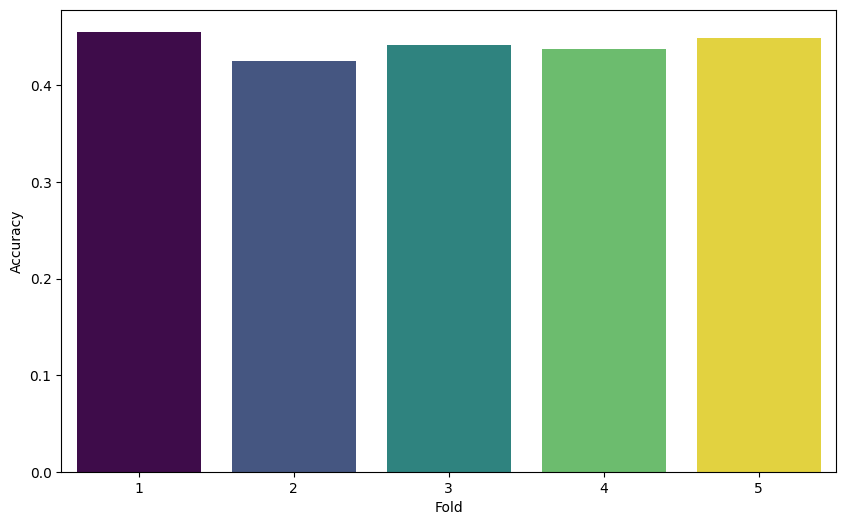

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting cross-validation scores
cv_results_df = pd.DataFrame({
    'Fold': range(1, num_folds + 1),
    'Accuracy': cv_scores
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Accuracy', data=cv_results_df, palette='viridis', hue='Fold', legend=False)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean Accuracy: {cv_scores.mean():.4f}')
plt.title('XGBoost K-Fold Cross-Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.ylim(0.55, 0.70) # Adjust y-axis for better visualization of scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Implement Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Initialize the XGBoost Classifier
# num_class should be determined by the unique values in y_train
# It's good practice to ensure the number of classes is correctly identified
num_classes = len(np.unique(y_train))
model_for_grid_search = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=model_for_grid_search,
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation as an example
    scoring='accuracy',
    verbose=2,
    n_jobs=-1 # Use all available CPU cores
)

print("Starting Grid Search...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nGrid Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))


Starting Grid Search...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Grid Search completed!
Best parameters found:  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Best cross-validation accuracy: 0.5819


##Implement Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution for XGBoost
param_distributions = {
    'n_estimators': randint(50, 200), # Number of boosting rounds
    'max_depth': randint(3, 10),      # Maximum tree depth
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage to prevent overfitting
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4) # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost Classifier
# num_class should be determined by the unique values in y_train
num_classes = len(np.unique(y_train))
model_for_random_search = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42
)

# Instantiate RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled
random_search = RandomizedSearchCV(
    estimator=model_for_random_search,
    param_distributions=param_distributions,
    n_iter=50, # Sample 50 different parameter combinations
    cv=3,      # Using 3-fold cross-validation
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

print("Starting Random Search...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\nRandom Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(random_search.best_score_))

Starting Random Search...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Random Search completed!
Best parameters found:  {'colsample_bytree': np.float64(0.9395655297064336), 'learning_rate': np.float64(0.22651885634946198), 'max_depth': 9, 'n_estimators': 191, 'subsample': np.float64(0.7975182385457563)}
Best cross-validation accuracy: 0.6281


##Compare Search Results

In [ ]:
# Retrieve best parameters and score from Grid Search
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

# Retrieve best parameters and score from Random Search
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_

print("\n============================================================")
print("COMPARISON OF HYPERPARAMETER SEARCH RESULTS")
print("============================================================")

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {best_params_grid}")
print(f"Best Cross-Validation Accuracy: {best_score_grid:.4f}")

print("\n--- Random Search Results ---")
print(f"Best Parameters: {best_params_random}")
print(f"Best Cross-Validation Accuracy: {best_score_random:.4f}")

print("\n============================================================")
print("CONCLUSION")
print("============================================================")

if best_score_grid > best_score_random:
    print(f"Grid Search yielded a better model configuration with an accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
elif best_score_random > best_score_grid:
    print(f"Random Search yielded a better model configuration with an accuracy of {best_score_random:.4f}.")
    print(f"Optimal Parameters (Random Search): {best_params_random}")
else:
    print(f"Both Grid Search and Random Search yielded the same best accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
    print(f"Optimal Parameters (Random Search): {best_params_random}")


COMPARISON OF HYPERPARAMETER SEARCH RESULTS

--- Grid Search Results ---
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Best Cross-Validation Accuracy: 0.5819

--- Random Search Results ---
Best Parameters: {'colsample_bytree': np.float64(0.9395655297064336), 'learning_rate': np.float64(0.22651885634946198), 'max_depth': 9, 'n_estimators': 191, 'subsample': np.float64(0.7975182385457563)}
Best Cross-Validation Accuracy: 0.6281

CONCLUSION
Random Search yielded a better model configuration with an accuracy of 0.6281.
Optimal Parameters (Random Search): {'colsample_bytree': np.float64(0.9395655297064336), 'learning_rate': np.float64(0.22651885634946198), 'max_depth': 9, 'n_estimators': 191, 'subsample': np.float64(0.7975182385457563)}


##Retrain Model with Best Parameters

In [ ]:
print("\n" + "="*60)
print("RETRAINING XGBOOST MODEL WITH BEST PARAMETERS")
print("="*60)

# Identify the best parameters from Random Search
best_params = random_search.best_params_

# Initialize a new XGBClassifier model using these best parameters
num_classes = len(np.unique(y_train))
final_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42,
    **best_params
)

# Train this new model using the entire training dataset
final_model.fit(X_train, y_train)

print("Final XGBoost model retrained successfully with optimal parameters!")


RETRAINING XGBOOST MODEL WITH BEST PARAMETERS
Final XGBoost model retrained successfully with optimal parameters!


##EVALUATING FINAL MODEL PERFORMANCE

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("\n" + "="*60)
print("EVALUATING FINAL MODEL PERFORMANCE ON TEST SET")
print("="*60)

# Make predictions on the test set using the final model
y_pred_final = final_model.predict(X_test)

# Calculate overall accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Model Accuracy on Test Set: {final_accuracy:.4f}")

# Generate a comprehensive classification report
print("\nClassification Report for Final Model:")
print(classification_report(y_test, y_pred_final, target_names=le_growth_category.classes_))


EVALUATING FINAL MODEL PERFORMANCE ON TEST SET
Final Model Accuracy on Test Set: 0.6478

Classification Report for Final Model:
              precision    recall  f1-score   support

     decline       0.62      0.75      0.68      2680
 high_growth       0.69      0.69      0.69      2728
      stable       0.14      0.02      0.03       592

    accuracy                           0.65      6000
   macro avg       0.48      0.48      0.47      6000
weighted avg       0.61      0.65      0.62      6000

